In [1]:
%load_ext autoreload
%autoreload 2

In [2]:

import pandas as pd
import numpy as np

from fairSV.fair_shapley import FairShapley

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from matplotlib.cm import ScalarMappable
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from sklearn.inspection import DecisionBoundaryDisplay

import warnings
warnings.filterwarnings('ignore')

FOLDER_PLOTS = 'figs/SV_plots/'

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap, LinearSegmentedColormap



# SV for LFWA experiment

In [4]:
df_lfwa_SV = pd.read_pickle('results/SV/lfwa_SV.pkl')
df_lfwa_SV_matrix_np = pd.read_pickle("results/SV/lfwa_SV_matrix.pkl")
df_lfwa_SV_matrix = pd.read_pickle("results/SV/lfwa_SV_matrix_df.pkl")

df_lfwa_emb = pd.read_pickle('results/embeddings/lfwa_embeddings.pkl')
df_ff_emb = pd.read_pickle('results/embeddings/ff_embeddings.pkl')
df_lfwa_emb_train = df_lfwa_emb[df_lfwa_emb.partition==0].copy()
df_ff_emb_val = df_ff_emb[df_ff_emb.partition==1].copy()

X_train = df_lfwa_emb_train.filter(regex='^e_dim').values
y_train = df_lfwa_emb_train.Male.values
print('Training samples', X_train.shape)

X_test = df_ff_emb_val.filter(regex='^e_dim').values
y_test = df_ff_emb_val.Male.values
print('Testing samples',X_test.shape)

Training samples (9525, 1792)
Testing samples (17349, 1792)


In [18]:
sc = StandardScaler()
sc.fit(X_train)
X_tr_sc = sc.transform(X_train)
X_tst_sc = sc.transform(X_test)
X_tr_sc.shape, X_tst_sc.shape, 

((9525, 1792), (17349, 1792))

**Compute SVs if the SVs are not preloaded**

In [ ]:
df_lfwa_SV.columns

In [ ]:
assert(df_lfwa_SV.shape[0] == df_lfwa_SV_matrix.shape[0] == df_lfwa_emb_train.shape[0] == X_train.shape[0])
assert((df_lfwa_SV.index == df_lfwa_emb_train.index).all())


assert(df_lfwa_SV_matrix.shape[1] == df_ff_emb_val.shape[0] == X_test.shape[0])
assert((df_lfwa_SV_matrix.columns == df_ff_emb_val.index).all())

## Take measures from SV that could be used for fairness measures

Diferencia entre las medias (*o diff en distribuciones*) de lo que aportan al accuracy cada uno de los grupos (diff or log or whatever)

In [ ]:
df_lfwa_SV[df_lfwa_SV.Male==1].SV_acc.mean(), df_lfwa_SV[df_lfwa_SV.Male==0].SV_acc.mean()

In [ ]:
# distrib1: with SV arrays
df_lfwa_SV[df_lfwa_SV.Male==1].SV_acc.shape, df_lfwa_SV[df_lfwa_SV.Male==0].SV_acc.shape

In [ ]:
df_lfwa_SV['SV_acc_scaled'] = df_lfwa_SV['SV_acc']-df_lfwa_SV['SV_acc'].min()
df_lfwa_SV['SV_acc_truncated'] = df_lfwa_SV['SV_acc']
df_lfwa_SV['SV_acc_truncated'][df_lfwa_SV['SV_acc_truncated']<0]=0 

plt.figure(figsize=(21,7))
plt.subplot(1,3,1)
sns.histplot(data=df_lfwa_SV, x='SV_acc',hue='Male', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
             log_scale=(False, True), alpha=0.3).set_title("$SV_{acc}$")

plt.subplot(1,3,2)
sns.histplot(data=df_lfwa_SV, x='SV_acc_scaled',hue='Male', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
             log_scale=(False, True), alpha=0.3).set_title("$SV_{acc}$ Desplazada")


plt.subplot(1,3,3)
sns.histplot(data=df_lfwa_SV, x='SV_acc_truncated',hue='Male', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
             log_scale=(False, True), alpha=0.3).set_title("$SV_{acc}$ Truncada")

plt.suptitle('$SV_{acc}$ versions for reweighting')
plt.tight_layout()
             
#plt.savefig(FOLDER_PLOTS+'LFWA/hist_sv_acc_trunc_despl.png')
plt.show()
plt.close()

In [ ]:
# Distrib2: beyond arrays: straightforward to the SV matrix
dists_sv_acc_fem = df_lfwa_SV_matrix[df_lfwa_emb_train.Male==0] #ditributional
dists_sv_acc_male =df_lfwa_SV_matrix[df_lfwa_emb_train.Male==1] #ditributional

# Por ejemplo:
dists_sv_acc_fem.mean().shape, dists_sv_acc_male.mean().shape

Diferencia entre las medias (*o diff en distribuciones*) de lo que aportan a SU accuracy cada uno de los grupos (diff or log or whatever)

In [ ]:
df_lfwa_SV[df_lfwa_SV.Male==1].SV_tpr.mean(), df_lfwa_SV[df_lfwa_SV.Male==0].SV_tnr.mean()

Resta de lo que **contribuye a su clase** VS lo que **contribuye a la clase contraria**

In [ ]:
df_lfwa_SV.SV_tp_diff[df_lfwa_SV.Male==1].mean(), df_lfwa_SV.SV_tp_diff[df_lfwa_SV.Male==0].mean()

In [ ]:
plt.figure(figsize=(21,7))
plt.subplot(1,3,1)
sns.histplot(data=df_lfwa_SV, x='SV_tp_diff',hue='Male', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
             log_scale=(True, False), alpha=0.3, kde=True, line_kws={'linewidth': 4}).set_title("Log - Normal")
             
plt.subplot(1,3,2)
sns.histplot(data=df_lfwa_SV, x='SV_tp_diff',hue='Male', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
             log_scale=(False, True), alpha=0.3).set_title("Normal - Log")

plt.subplot(1,3,3)
sns.histplot(data=df_lfwa_SV, x='SV_tp_diff',hue='Male', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
             log_scale=(True, True), alpha=0.3, kde=True, line_kws={'linewidth': 4}).set_title("log - log")

plt.suptitle('$SV_{TPR} - SV_{TNR}$ if $y_i=1$\n$SV_{TNR} - SV_{TPR}$ if $y_i=0$')
plt.tight_layout()

#plt.savefig(FOLDER_PLOTS+'LFWA/hist_sv_tp.png')
plt.show()
plt.close()

### SV_TPR - SV_FPR (given TP for each class)

$$SV_{TPR} - SV_{FPR} = SV_{TPR} - (\frac{1}{N} - SV_{TNR}) = SV_{TPR} + SV_{TNR} - \frac{1}{N}$$
$$SV_{TNR} - SV_{FNR} = SV_{TNR} - (\frac{1}{N} - SV_{TPR}) = SV_{TPR} + SV_{TNR} - \frac{1}{N}$$

In [ ]:
df_lfwa_SV[df_lfwa_SV.Male==1].SV_EOp.mean(), df_lfwa_SV[df_lfwa_SV.Male==0].SV_EOp.mean()

In [ ]:

plt.figure(figsize=(21,7))
plt.subplot(1,3,1)
sns.histplot(data=df_lfwa_SV, x='SV_EOp',hue='Male', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
             log_scale=(True, False), alpha=0.5, kde=True, line_kws={'linewidth': 4}).set_title("Log - Normal")
             
plt.subplot(1,3,2)
sns.histplot(data=df_lfwa_SV, x='SV_EOp',hue='Male', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
             log_scale=(False, True), alpha=0.5).set_title("Normal - Log")

plt.subplot(1,3,3)
sns.histplot(data=df_lfwa_SV, x='SV_EOp',hue='Male', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
             log_scale=(True, True), alpha=0.5).set_title("Log - Log")
plt.suptitle('$SV_{EOp}$')

plt.tight_layout()
#plt.savefig(FOLDER_PLOTS+'LFWA/hist_sv_EOp.png')
plt.show()
plt.close()

In [ ]:

plt.figure(figsize=(21,7))
plt.subplot(1,3,1)
sns.histplot(data=df_lfwa_SV, x='SV_EOp_bounded',hue='Male', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
             log_scale=(True, False), alpha=0.5, kde=True, line_kws={'linewidth': 4}).set_title("Log - Normal")
             
plt.subplot(1,3,2)
sns.histplot(data=df_lfwa_SV, x='SV_EOp_bounded',hue='Male', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
             log_scale=(False, True), alpha=0.5).set_title("Normal - Log")

plt.subplot(1,3,3)
sns.histplot(data=df_lfwa_SV, x='SV_EOp_bounded',hue='Male', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
             log_scale=(True, True), alpha=0.5).set_title("Log - Log")
plt.suptitle('$SV_{EOp_{bounded}}$')

plt.tight_layout()
#plt.savefig(FOLDER_PLOTS+'LFWA/hist_sv_EOp_bounded.png')
plt.show()
plt.close()

### Figure histogram

In [19]:
sns.set_theme(style="darkgrid", palette="deep", font='serif')
sns.set_context("paper", font_scale=1.5)
plt.style.use('classic')

In [20]:
df_lfwa_SV['Gender']=df_lfwa_SV['Male'].map({0:'Female',1:'Male'})

In [21]:
colors = [(250/255,70/255,22/255),(6/255,78/255,64/255)]
colors = [(243/255,144/255,76/255), (58/255,143/255,102/255)] #pastel

cmap_hist = mpl.colors.ListedColormap(colors)
highlight_color = (42/255, 245/255, 152/255)

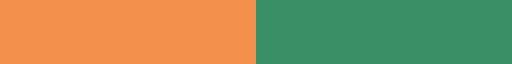

In [22]:
cmap_hist

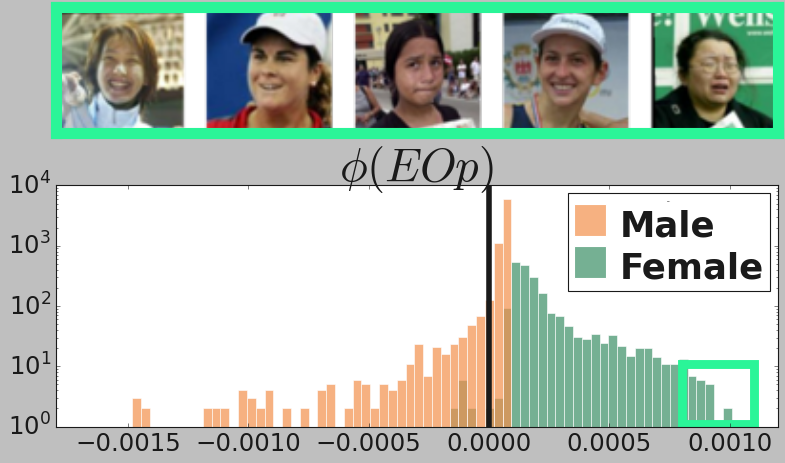

In [23]:
f,_ = plt.subplot_mosaic(
"""
0
1
""", figsize=(10,6), gridspec_kw={'height_ratios': [.55, 1]})
axs = f.get_axes()

im = plt.imread("figs/top5imgssveop.png")
axs[0].imshow(im)
axs[0].set_frame_on(True)
axs[0].spines['left'].set_color(highlight_color)
axs[0].spines['right'].set_color(highlight_color)
axs[0].spines['bottom'].set_color(highlight_color)
axs[0].spines['top'].set_color(highlight_color)

axs[0].spines['left'].set_linewidth(10)
axs[0].spines['right'].set_linewidth(10)
axs[0].spines['bottom'].set_linewidth(10)
axs[0].spines['top'].set_linewidth(10)

# Remove the grid
axs[0].grid(False)
axs[0].set_xlabel('')
axs[0].set_ylabel('')
axs[0].set_yticklabels([])
axs[0].set_xticklabels([])
axs[0].set_xticks([])
axs[0].set_yticks([])

ax = axs[1]
sns.histplot(data=df_lfwa_SV, x='SV_EOp_bounded',hue='Gender', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
             log_scale=(False, True), alpha=0.7, ax=ax,
             edgecolor='white', palette=colors, multiple='layer').set_title("$\phi(EOp)$", fontsize=42, fontweight='bold')
ax.set_xlim(-0.0018, 0.0012)
ax.axvline(0, color='k', linewidth=5)
rect = mpl.patches.Rectangle((0.0008,1.1),0.0003,10,linewidth=8,edgecolor=highlight_color,facecolor='none')

# Add the patch to the Axes
ax.add_patch(rect)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks(ax.get_xticks()[1:-1:1])
#ax.set_xticklabels(ax.get_xticklabels()[::2])
ax.tick_params(axis='both', which='major', labelsize=22)

plt.setp(ax.get_legend().get_texts(), fontsize='32', weight='bold') # for legend text
plt.setp(ax.get_legend().get_title(), fontsize='0') # for legend title
plt.setp(ax.get_legend().get_patches(), height=29)
plt.tight_layout()
plt.savefig('figs/histLFWAsvEOpPlusTop5.pdf', dpi=300, format='pdf',
            facecolor='w', edgecolor='w', transparent=False, bbox_inches='tight', pad_inches = 0)
plt.show()
plt.close()

## Get SV rankings

## Plot and hist plots

### Figure embeddings

In [5]:
sc = StandardScaler()
sstndr_whole = sc.fit_transform(np.vstack([X_train, X_test]))
X_train = sstndr_whole[:len(X_train)]
X_test = sstndr_whole[len(X_train):]


In [6]:
fair_sv_extractor = FairShapley(X_train, y_train, X_test, y_test,
                    show_plot=False, save_folder=FOLDER_PLOTS+'LFWA/',
                    SV=df_lfwa_SV_matrix.to_numpy())#save_folder='path, show_plot=True, SV=mySV

# Calculating TSNE


In [7]:
X_train_2d = fair_sv_extractor.X_tr_2dim.copy()
y_train = fair_sv_extractor.y_train.copy()

In [8]:
X_test_2d = fair_sv_extractor.X_tst_2dim.copy()
y_tst = fair_sv_extractor.y_test.copy()

In [9]:
X_train_2d[:,0], X_train_2d[:,1] = X_train_2d[:,1].copy(), X_train_2d[:,0].copy()
X_test_2d[:,0], X_test_2d[:,1] = X_test_2d[:,1].copy(), X_test_2d[:,0].copy()

In [39]:
plt.style.use('default')
sns.set_theme(style="darkgrid", palette="deep", font='serif')
sns.set_context("paper", font_scale=1.5)


In [ ]:
cmap = 'Set2' # sns.color_palette(cmap)

In [10]:
cmap = mpl.colors.ListedColormap([(6/255,78/255,64/255),(250/255,70/255,22/255)])
cmap = mpl.colors.ListedColormap([(58/255,143/255,102/255),(243/255,144/255,76/255)])

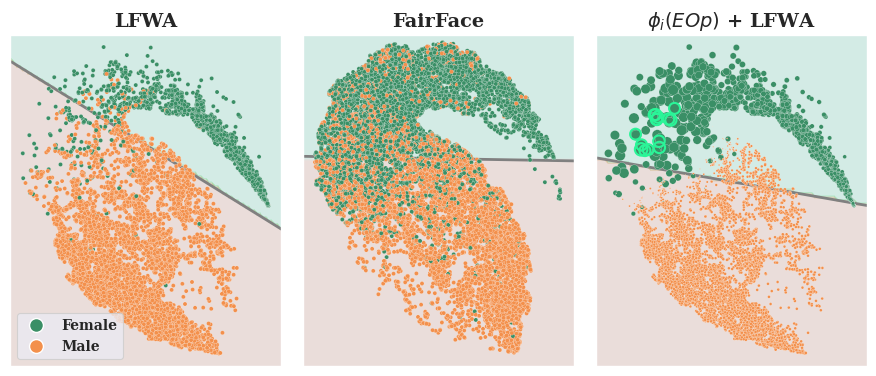

In [51]:
f, axs = plt.subplots(1,3, figsize=(9,4)) #9,4 original

show_grid = False
title_size = 14
bound_type = 'predict'
legend_size = 10
point_alpha = 1
bound_alpha = 0.1
node_size=9
point_edge='w'
point_line=0.15
model = LogisticRegression # GradientBoostingClassifier, LogisticRegression, MLPClassifier,SVC

colors = [(0,1,0.5),(1,0.4,0)]
#colors = (58/255,143/255,102/255),(243/255,144/255,76/255)
cm = LinearSegmentedColormap.from_list(
        "Custom", colors, N=20)

highlight_color = (42/255, 245/255, 152/255)


for ax in axs:
    ax.set_xlim(np.min(X_train_2d[:,0])-3, np.max(X_train_2d[:,0])+3)
    ax.set_ylim(np.min(X_train_2d[:,1])-3, np.max(X_train_2d[:,1])+3)
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.grid(show_grid)
    #ax.axis('off')

#============================
#============================

sct = axs[0].scatter(X_train_2d[:,0],X_train_2d[:,1], c=y_train,
                     cmap = cmap, s=node_size, alpha=point_alpha, 
                     edgecolor=point_edge, linewidth=point_line)
axs[0].set_title('LFWA', fontsize=title_size, weight='bold')

clf = model(random_state=42)
clf.fit(X_train_2d, y_train)
DecisionBoundaryDisplay.from_estimator(
    clf, X_train_2d, cmap=cm, alpha=bound_alpha, ax=axs[0], eps=4,
    response_method=bound_type, zorder=0)
# Create a legend
label_dict = {0: 'Female', 1: 'Male'}
legend_labels = np.unique(y_train)
legend_handles = [plt.Line2D([0], [0], marker='o', color='w',
                             markerfacecolor=cmap(i), linestyle='', markersize=10) for i in legend_labels]
leg = axs[0].legend(legend_handles, [label_dict[label] for label in legend_labels],
                    loc='lower left',
                    prop={'weight':'bold', 'size':legend_size})
leg.get_frame().set_alpha(0.8)

#============================
#============================


clf = model(random_state=42)

clf.fit(X_test_2d, y_tst)
DecisionBoundaryDisplay.from_estimator(
    clf, X_test_2d, cmap=cm, alpha=bound_alpha, ax=axs[1], eps=4,
    response_method="predict", zorder=0)

axs[1].scatter(X_test_2d[:,0],X_test_2d[:,1], c=y_tst,
               cmap = cmap, s=node_size, alpha=point_alpha,
               edgecolor=point_edge, linewidth=point_line)
axs[1].set_title('FairFace', fontsize=title_size, weight='bold')


#============================
#============================

weights = fair_sv_extractor.sv_eop_bounded.copy()
weights[weights<0] =0

s_weights = (weights-np.min(weights))/(np.max(weights)-np.min(weights))
s_weights = (s_weights / np.sum(s_weights))*len(s_weights)

clf = model(random_state=42)

clf.fit(X_train_2d, y_train, sample_weight=s_weights)
DecisionBoundaryDisplay.from_estimator(
    clf, X_train_2d, cmap=cm, alpha=bound_alpha, ax=axs[2], eps=4,
    response_method="predict", zorder=0)

size = weights/np.max(weights)*9*node_size
axs[2].scatter(X_train_2d[:,0],X_train_2d[:,1], c=y_train,
               cmap=cmap, alpha=point_alpha, s=size,
               edgecolor=point_edge, linewidth=point_line)
idx_max = np.argsort(size)[::-1][:15]
axs[2].scatter(X_train_2d[idx_max,0], X_train_2d[idx_max,1], marker='o',
                                s=size[idx_max], facecolor="none", edgecolors=highlight_color, linewidth=1.2)

axs[2].set_title('$\phi_i(EOp)$ + LFWA', fontsize=title_size, weight='bold')
#plt.subplots_adjust(wspace=-10.2, hspace=0.2)


"""axs[0].plot([31, -9.5],[-30, 34], linewidth=3, color='grey', zorder=0)
axs[1].plot([8.4, 7.3],[-30, 34], linewidth=3, color='grey', zorder=0)
axs[2].plot([9.5, -3],[-30, 34], linewidth=3, color='grey')"""

axs[0].plot([-30, 34], [31, -9.5], linewidth=2, color='grey', zorder=0)
axs[1].plot([-30, 34], [8.4, 7.3], linewidth=2, color='grey', zorder=0)
axs[2].plot([-30, 34], [8, -3.5], linewidth=2, color='grey', zorder=0)

plt.tight_layout()
#plt.savefig('figs/SVimgembeddingB.pdf', dpi=300, format='pdf',
#            facecolor='w', edgecolor='w', transparent=False, bbox_inches='tight', pad_inches = 0)
#plt.savefig('figs/SVimgembeddingB.png', dpi=150, format='png',
#           facecolor='w', edgecolor='w', transparent=True, bbox_inches='tight', pad_inches = 0)
plt.show()

**Subplot less points**

In [ ]:
N_subset = 1500
#N_subset = X_train_2d.shape[0]

idx_train_rndm = np.random.choice(np.arange(X_train_2d.shape[0]), N_subset)
idx_tst_rndm = np.random.choice(np.arange(X_train_2d.shape[0]), N_subset)

X_train_2d_rnd = X_train_2d[idx_train_rndm]
y_train_rnd = y_train[idx_train_rndm]

X_test_2d_rnd = X_test_2d[idx_tst_rndm]
y_tst_rnd = y_tst[idx_tst_rndm]


In [ ]:
f, axs = plt.subplots(1,3, figsize=(9,4))

show_grid = False
title_size = 14
bound_type = 'predict'
legend_size = 12
point_alpha = 1
bound_alpha = 0.3
node_size=15
point_edge='w'
point_line=0.00
model = LogisticRegression # GradientBoostingClassifier, LogisticRegression, MLPClassifier,SVC

colors = [(0.5,0.1,1), (0,1,0.5)]
cm = LinearSegmentedColormap.from_list(
        "Custom", colors, N=20)


for ax in axs:
    ax.set_xlim(np.min(X_train_2d[:,0])-3, np.max(X_train_2d[:,0])+3)
    ax.set_ylim(np.min(X_train_2d[:,1])-3, np.max(X_train_2d[:,1])+3)
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.grid(show_grid)
    #ax.axis('off')

#============================
#============================

sct = axs[0].scatter(X_train_2d_rnd[:,0],X_train_2d_rnd[:,1], c=y_train_rnd,
                     cmap = cmap, s=node_size, alpha=point_alpha, 
                     edgecolor=point_edge, linewidth=point_line)
axs[0].set_title('LFWA', fontsize=title_size, weight='bold')

clf = model(random_state=42)
clf.fit(X_train_2d, y_train)
DecisionBoundaryDisplay.from_estimator(
    clf, X_train_2d, cmap=cm, alpha=bound_alpha, ax=axs[0], eps=4,
    response_method=bound_type, zorder=0)
# Create a legend
label_dict = {0: 'Female', 1: 'Male'}
legend_labels = np.unique(y_train)
legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap(i), markersize=10) for i in legend_labels]
leg = axs[0].legend(legend_handles, [label_dict[label] for label in legend_labels], prop={'weight':'bold', 'size':legend_size})
leg.get_frame().set_alpha(0.8)


#============================
#============================


clf = model(random_state=42)

clf.fit(X_test_2d, y_tst)
DecisionBoundaryDisplay.from_estimator(
    clf, X_test_2d, cmap=cm, alpha=bound_alpha, ax=axs[1], eps=4,
    response_method="predict", zorder=0)

axs[1].scatter(X_test_2d_rnd[:,0],X_test_2d_rnd[:,1], c=y_tst_rnd,
               cmap = cmap, s=node_size, alpha=point_alpha,
               edgecolor=point_edge, linewidth=point_line)
axs[1].set_title('FairFaces', fontsize=title_size, weight='bold')


#============================
#============================

weights = fair_sv_extractor.sv_acc
#weights[weights<0] =0

s_weights = (weights-np.min(weights))/(np.max(weights)-np.min(weights))
s_weights = (s_weights / np.sum(s_weights))*len(s_weights)

clf = model(random_state=42)

clf.fit(X_train_2d, y_train, sample_weight=s_weights)
DecisionBoundaryDisplay.from_estimator(
    clf, X_train_2d, cmap=cm, alpha=bound_alpha, ax=axs[2], eps=4,
    response_method="predict", zorder=0)

size = weights/np.max(weights)*9*node_size
size = size[idx_train_rndm]
axs[2].scatter(X_train_2d_rnd[:,0],X_train_2d_rnd[:,1], c=y_train_rnd,
               cmap=cmap, alpha=point_alpha, s=size,
               edgecolor=point_edge, linewidth=point_line)
idx_max = np.argsort(size)[::-1][:20]
axs[2].scatter(X_train_2d_rnd[idx_max,0], X_train_2d_rnd[idx_max,1], marker='o',
                                s=size[idx_max], facecolor="none", edgecolors='aqua', linewidth=0.8)

axs[2].set_title('$\phi_i(EOp)$ + LFWA', fontsize=title_size, weight='bold')
#plt.subplots_adjust(wspace=-10.2, hspace=0.2)


"""axs[0].plot([-30, 34], [31, -9.5], linewidth=3, color='orange')
axs[1].plot([-30, 34], [8.4, 7.3], linewidth=3, color='orange')
axs[2].plot([-30, 34], [9.5, -3], linewidth=3, color='orange')"""

plt.tight_layout()

#plt.savefig('figs/SVimgembeddingBSUBSET.pdf', dpi=300, format='pdf',
#           facecolor='w', edgecolor='w', transparent=False, bbox_inches='tight', pad_inches = 0)
#plt.savefig('figs/SVimgembeddingBSUBSET.png', dpi=150, format='png',
#            facecolor='w', edgecolor='w', transparent=False, bbox_inches='tight', pad_inches = 0)



plt.show()

In [ ]:
fair_sv_extractor.plot_data_sns(test=True, title='FeatureSpace', save=True)

In [ ]:
fair_sv_extractor.plot_data_sns(test=True, size_test=0, title='TRAIN_FeatureSpace', save=True)

In [ ]:
fair_sv_extractor.plot_data_sns(test=True, size=0,title='TEST_FeatureSpace', save=True)

In [ ]:
# get graphs of positive and negative SV for each measure
# get histogram of sv for each measure
sv_arrays = sorted([s for s in dir(fair_sv_extractor) if s .startswith('sv_')])
sv_arrays = ['sv_acc',
    'sv_max_acc_disp_diff',
    'sv_tp_diff',
    'sv_eop',
    'sv_eop_bounded',
    'sv_tpr',
    'sv_tnr',
    'sv_max_acc_disp_log'
 ]

for sv_arr_str in sv_arrays:
    array = eval(f'fair_sv_extractor.{sv_arr_str}')
    array = array.astype('float64')
    fair_sv_extractor.plot_data_sns(sv_array = array, size='sv_pos',test=False, save=True, title=sv_arr_str.upper()+'_pos')
    fair_sv_extractor.plot_data_sns(sv_array = array, size='sv_neg',test=False, save=True, title=sv_arr_str.upper()+'_neg')
    fair_sv_extractor.plot_sv_hist(sv_array = array, title=sv_arr_str, save=True)


## Reweigthing values

### Accuracy:
* Truncada
* desplazada

In [ ]:
df_lfwa_SV['SV_acc_scaled'] = df_lfwa_SV['SV_acc']-df_lfwa_SV['SV_acc'].min()
df_lfwa_SV['SV_acc_truncated'] = df_lfwa_SV['SV_acc']
df_lfwa_SV['SV_acc_truncated'][df_lfwa_SV['SV_acc_truncated']<0]=0 

plt.figure(figsize=(25,5))
plt.subplot(1,3,1)
sns.histplot(data=df_lfwa_SV, x='SV_acc',hue='Male', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
             log_scale=(False, True), alpha=0.3).set_title("$SV_{acc}$")

plt.subplot(1,3,2)
sns.histplot(data=df_lfwa_SV, x='SV_acc_scaled',hue='Male', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
             log_scale=(False, True), alpha=0.3).set_title("$SV_{acc}$ Desplazada")


plt.subplot(1,3,3)
sns.histplot(data=df_lfwa_SV, x='SV_acc_truncated',hue='Male', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
             log_scale=(False, True), alpha=0.3).set_title("$SV_{acc}$ Truncada")

plt.show()
plt.close()

In [ ]:
plt.figure(figsize=(21,7))
plt.subplot(1,3,1)
sns.histplot(data=df_lfwa_SV, x='SV_acc',hue='Male', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
             log_scale=(True, False), alpha=0.4, kde=True, line_kws={'linewidth': 4}).set_title("Log-normal")
             
plt.subplot(1,3,2)
sns.histplot(data=df_lfwa_SV, x='SV_acc',hue='Male', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
             log_scale=(False, True), alpha=0.4).set_title("normal-log")

plt.subplot(1,3,3)
sns.histplot(data=df_lfwa_SV, x='SV_acc',hue='Male', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
             log_scale=(True, True), alpha=0.4).set_title("log-log")
plt.suptitle('$SV_{Accuracy}$ histograms')
plt.tight_layout()
plt.savefig(FOLDER_PLOTS+'LFWA/hist_sv_acc.png')
plt.show()
plt.close()

### SV_EOp

In [ ]:

plt.figure(figsize=(21,7))
plt.subplot(1,3,1)
sns.histplot(data=df_lfwa_SV, x='SV_EOp',hue='Male', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
             log_scale=(True, False), alpha=0.5, kde=True, line_kws={'linewidth': 4}).set_title("Log - Normal")
             
plt.subplot(1,3,2)
sns.histplot(data=df_lfwa_SV, x='SV_EOp',hue='Male', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
             log_scale=(False, True), alpha=0.5).set_title("Normal - Log")

plt.subplot(1,3,3)
sns.histplot(data=df_lfwa_SV, x='SV_EOp',hue='Male', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
             log_scale=(True, True), alpha=0.5).set_title("Log - Log")
plt.suptitle('$SV_{EOp}$')
plt.tight_layout()
plt.show()
plt.close()

In [ ]:

plt.figure(figsize=(21,7))
plt.subplot(1,3,1)
sns.histplot(data=df_lfwa_SV, x='SV_EOp',hue='Male', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
             log_scale=(True, False), alpha=0.5, kde=True, line_kws={'linewidth': 4}).set_title("Log - Normal")
             
plt.subplot(1,3,2)
sns.histplot(data=df_lfwa_SV, x='SV_EOp',hue='Male', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
             log_scale=(False, True), alpha=0.5).set_title("Normal - Log")

plt.subplot(1,3,3)
sns.histplot(data=df_lfwa_SV, x='SV_EOp',hue='Male', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
             log_scale=(True, True), alpha=0.5).set_title("Log - Log")
plt.suptitle('$SV_{EOp}$ Bounded')
plt.tight_layout()
plt.show()
plt.close()

### Diff en lo que aportan a la clase vs lo que aportan a la contraria: SV_TPR - SV_TNR

In [ ]:

for sw_rw_m in df_lfwa_SV.columns.drop('Male').drop('SV_acc_scaled').drop('SV_acc_truncated').drop('SV_acc').drop('SV_EOp'):
    plt.figure(figsize=(7,7))

                
    sns.histplot(data=df_lfwa_SV, x=sw_rw_m,hue='Male', bins=int(np.sqrt(df_lfwa_SV.shape[0])),
                log_scale=(False, True), alpha=0.3).set_title("Normal - Log")



    plt.suptitle(sw_rw_m)

    plt.tight_layout()
    plt.show()


### Fair SV?
When A=Y not seem very usefull
TPR, TNR, DIFF, log_diff?